In [1]:
import os
os.chdir("..")
import numpy as np
from scipy.sparse import diags
from scipy.linalg import solve
import matplotlib.pyplot as plt

In [2]:
def generate_long_test_data(n_points=30, dt=0.5, pos_noise=0.15, theta_noise=0.02):
    t = np.arange(n_points) * dt
    v_true = 2.0 + 0.2 * t + 0.5 * np.sin(0.3 * t)
    
    kappa_true = 0.08 * np.sin(0.2 * t) 
    
    x, y, theta = np.zeros(n_points), np.zeros(n_points), np.zeros(n_points)
    
    for i in range(n_points - 1):
        a_now = (v_true[i+1] - v_true[i]) / dt
        d_theta = (v_true[i] * dt + 0.5 * a_now * dt**2) * kappa_true[i]
        theta[i+1] = theta[i] + d_theta
        x[i+1] = x[i] + (dt/2) * (v_true[i]*np.cos(theta[i]) + v_true[i+1]*np.cos(theta[i+1]))
        y[i+1] = y[i] + (dt/2) * (v_true[i]*np.sin(theta[i]) + v_true[i+1]*np.sin(theta[i+1]))

    waypoints = np.stack([x, y, theta], axis=1)
    accel_long = np.gradient(v_true, dt)
    accel_array = np.stack([accel_long, np.zeros_like(accel_long)], axis=1)

    np.random.seed(42) 
    x_noisy = x + np.random.normal(0, pos_noise, n_points)
    y_noisy = y + np.random.normal(0, pos_noise, n_points)
    theta_noisy = theta + np.random.normal(0, theta_noise, n_points)
    
    waypoints_noisy = np.stack([x_noisy, y_noisy, theta_noisy], axis=1)
        
    return waypoints_noisy, v_true, accel_array

In [3]:
def lsm_tikhonov(x, y, theta, v0, a0, dt, lambda_reg=0.1):
    n = len(x)
    num_vars = n - 1  # acceleration steps
    
    # v_{i+1} = v_i + a_i * dt
    # v_target = sqrt((dx/dt)^2 + (dy/dt)^2)
    v_gt = np.sqrt((np.diff(x)/dt)**2 + (np.diff(y)/dt)**2) # length n-1
    
    # v_k = v0 + dt * sum_{j=0}^{k-1} a_j
    # A * a = v_gt - v0
    A = np.tril(np.ones((num_vars, num_vars))) * dt
    target = v_gt - v0
    
    # A_sub * a_unknown = target - A[:, 0]*a0
    A_sub = A[:, 1:]
    target_sub = target - A[:, 0] * a0
    
    # Tikhonov Matrix D (penalizes change in acceleration: jerk)
    num_unknowns = num_vars - 1
    D = np.zeros((num_unknowns, num_unknowns))
    for i in range(num_unknowns - 1):
        D[i, i] = -1
        D[i, i+1] = 1
        
    # (A.T @ A + lambda * D.T @ D) a = A.T @ target
    # a[0] = a0
    lhs = A_sub.T @ A_sub + lambda_reg * D.T @ D
    rhs = A_sub.T @ target_sub
    a_unknown = solve(lhs, rhs)
    accel = np.concatenate(([a0], a_unknown))
    
    # Reconstruct smooth velocity
    v_smooth = np.zeros(n)
    v_smooth[0] = v0 # initial velocity
    for i in range(num_vars):
        v_smooth[i+1] = v_smooth[i] + accel[i] * dt

    # curvature (kappa)
    # theta_{i+1} = theta_i + dt*k*v + (dt^2/2)*k*a
    # theta_{i+1} - theta_i = kappa_i * (dt * v_i + 0.5 * dt^2 * a_i)
    d_theta = np.diff(theta)
    denom = (v_smooth[:-1] * dt + 0.5 * accel * dt**2)
    
    # Tikhonov for kappa (penalizes steering rate)
    # (diag(coeff)^2 + lambda * D.T @ D) kappa = diag(coeff) @ d_theta
    W = np.diag(denom)
    D_k = np.zeros((num_vars - 1, num_vars))
    for i in range(num_vars - 1):
        D_k[i, i] = -1
        D_k[i, i+1] = 1
    lhs_k = W.T @ W + lambda_reg * D_k.T @ D_k
    rhs_k = W.T @ d_theta
    kappa = solve(lhs_k, rhs_k)

    return accel, kappa, v_smooth

def compute_action(waypoints, dt, v0, a0) -> str:
    # waypoints = waypoints.cpu().numpy()
    x_seq = waypoints[:, 0]
    y_seq = waypoints[:, 1]
    theta_seq = waypoints[:, 2]
    accel_seq, kappa_seq, v_smooth = lsm_tikhonov(x_seq, y_seq, theta_seq, v0, a0, dt)
    action_list = [f"({a:.4f}, {k:.4f})" for a, k in zip(accel_seq, kappa_seq)]
    action = ", ".join(action_list)
    return action

def compute_trajectory(accel, kappa, x0, y0, theta0, v0, dt):
    n = len(accel) + 1
    
    x = np.zeros(n)
    y = np.zeros(n)
    theta = np.zeros(n)
    v = np.zeros(n)
    
    x[0], y[0], theta[0], v[0] = x0, y0, theta0, v0
    
    for i in range(len(accel)):
        # update velocity v
        v[i+1] = v[i] + accel[i] * dt
        
        # theta^{i+1} = theta^i + dt * k^i * v^i + (dt^2 / 2) * k^i * a^i
        theta[i+1] = theta[i] + dt * kappa[i] * v[i] + (0.5 * dt**2) * kappa[i] * accel[i]
        
        # x^{i+1} = x^i + (dt/2) * (v^i*cos(theta^i) + v^{i+1}*cos(theta^{i+1}))
        x[i+1] = x[i] + (dt / 2.0) * (v[i] * np.cos(theta[i]) + v[i+1] * np.cos(theta[i+1]))
        y[i+1] = y[i] + (dt / 2.0) * (v[i] * np.sin(theta[i]) + v[i+1] * np.sin(theta[i+1]))
        
    return x, y, theta, v

In [4]:
pre_waypoints = np.array([
    [-4.6067e+00,  1.2379e-03,  1.7392e-02],
    [-3.2583e+00,  1.1003e-02,  1.5550e-02],
    [-2.0444e+00,  8.1606e-03,  1.5040e-02],
    [-9.6234e-01,  7.8840e-03,  1.2112e-02]
])

velocity = np.array([2.5, 2.6, 2.7, 2.65])
acceleration = np.array([[0.2, 0.0], [0.1, 0.0], [0.15, 0.0], [0.05, 0.0]])

In [5]:
v0 = velocity[-1].item()
a0 = acceleration[-1][0].item()
dt = 0.5

In [6]:
accel, kappa, v_smooth = lsm_tikhonov(pre_waypoints[:, 0], pre_waypoints[:, 1], pre_waypoints[:, 2], v0, a0, dt, lambda_reg=0.1)

In [7]:
print("Accel:", accel)
print("Kappa:", kappa) 

Accel: [ 0.05       -0.50318308 -0.51417858]
Kappa: [-0.00133977 -0.00056185 -0.00241131]


In [8]:
_x, _y, _theta, _v = compute_trajectory(accel, kappa, pre_waypoints[:, 0][0], pre_waypoints[:, 1][0], pre_waypoints[:, 2][0], v0, dt)

In [9]:
print("reconstructed x:", _x)
print("reconstructed y:", _y)
print("reconstructed theta:", _theta)
print("reconstructed v:", _v)

reconstructed x: [-4.6067     -3.27563165 -2.00117818 -0.85385327]
reconstructed y: [0.0012379  0.02319724 0.04265715 0.05824611]
reconstructed theta: [0.017392   0.01560844 0.0148923  0.01212548]
reconstructed v: [2.65       2.675      2.42340846 2.16631917]


In [10]:
action = compute_action(pre_waypoints, dt, v0, a0)

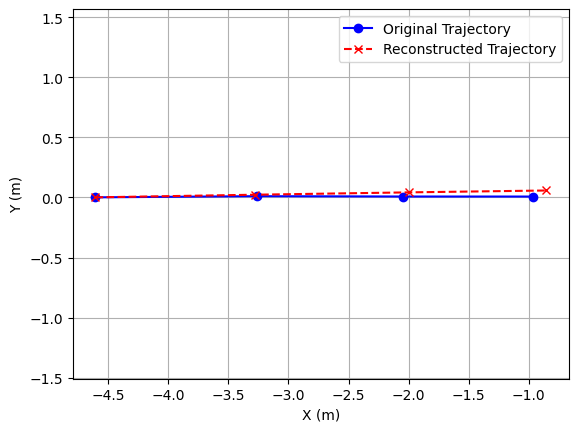

In [11]:
plt.plot(pre_waypoints[:, 0], pre_waypoints[:, 1], 'bo-', label='Original Trajectory')
plt.plot(_x, _y, 'rx--', label='Reconstructed Trajectory')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

In [12]:
n_steps = 30
dt = 0.5
test_waypoints, test_velocity, test_accel = generate_long_test_data(n_steps, dt)
v0_test = test_velocity[0]
a0_test = test_accel[0, 0]

In [13]:
accel_lsm, kappa_lsm, v_smooth_lsm = lsm_tikhonov(
    test_waypoints[:, 0], 
    test_waypoints[:, 1], 
    test_waypoints[:, 2], 
    v0_test, a0_test, dt, lambda_reg=0.1
)

rec_x, rec_y, rec_theta, rec_v = compute_trajectory(
    accel_lsm, kappa_lsm, 
    test_waypoints[0, 0], test_waypoints[0, 1], test_waypoints[0, 2], 
    v0_test, dt
)

final_error = np.linalg.norm(test_waypoints[-1, :2] - np.array([rec_x[-1], rec_y[-1]]))
print(f"Steps: {n_steps} ")
print(f"Final error: {final_error:.4f}")

Steps: 30 
Final error: 0.3857


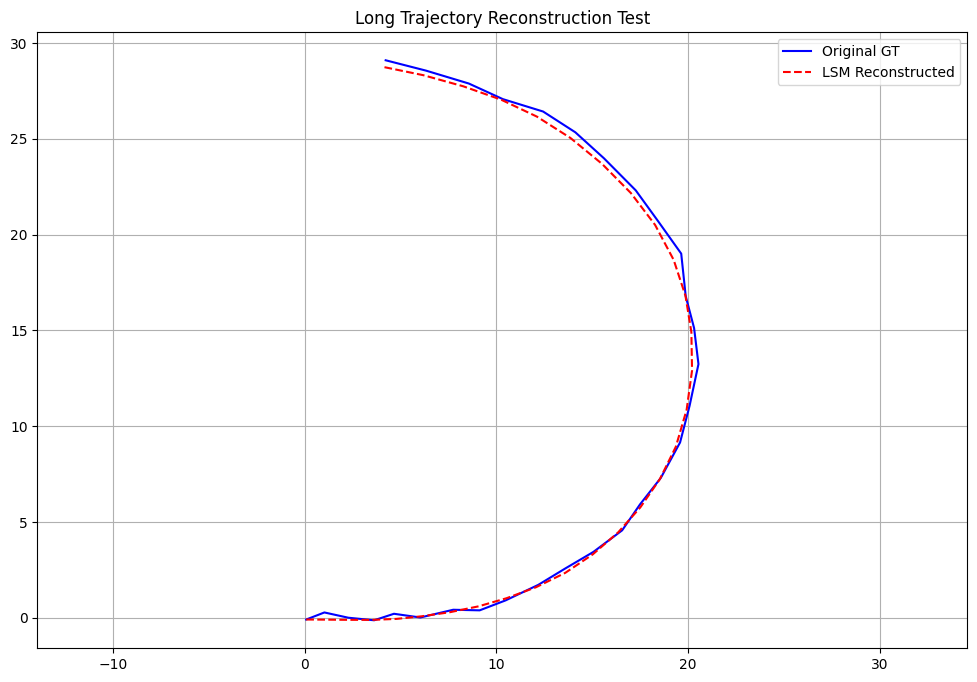

In [14]:
plt.figure(figsize=(12, 8))
plt.plot(test_waypoints[:, 0], test_waypoints[:, 1], 'b-', label='Original GT')
plt.plot(rec_x, rec_y, 'r--', label='LSM Reconstructed')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title("Long Trajectory Reconstruction Test")
plt.show()